# Idealized non-ITF global adjustment

This example isolates the model mechanics on a deliberately simple domain.
It uses the definitive **no-Indonesian-Throughflow** topology: closed Indian
and Pacific basins connected to a step-shaped Atlantic through the southern
transition regions.

**Geometry.** $H=1000$ m; $y_S=-54^\circ$, $y_P=-42^\circ$,
$y_I=-34^\circ$, and the Atlantic northern closure is $54^\circ$N.

**Forcing.** The input is vector Ekman transport itself, not wind stress:
$\mathbf{M}_{\mathrm{Ek}}$ is a smooth, basin-tapered oscillation. The northern
transport combines an 8 Sv pulse and a six-year oscillation. The southern
transport is derived from the same $M_{\mathrm{Ek},y}$ field.

The plots are a geometry schematic, time/latitude Hovmöllers, and a transfer
amplitude (damping-factor) contour against **linear period**. No forcing
spectra are plotted.

Throughout, $h_b$ is evaluated at $x_b$, outside the western boundary-current
region rather than at the coastline; $h_w$ is the western-boundary thickness,
not a westward-propagating thickness.

In [1]:
from pathlib import Path
import sys
import warnings

import cmocean
from dask.array.core import PerformanceWarning
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(REPO / "notebooks"))

from moc_adjustment_theory import GlobalAdjustmentModel, GlobalForcing
from _example_helpers import (
    non_itf_geometry,
    non_itf_taper,
    plot_geometry,
    section_transport,
    stitched_atlantic,
)

plt.rcParams.update({"figure.dpi": 115, "axes.grid": False})
warnings.filterwarnings("ignore", category=PerformanceWarning)

## Geometry

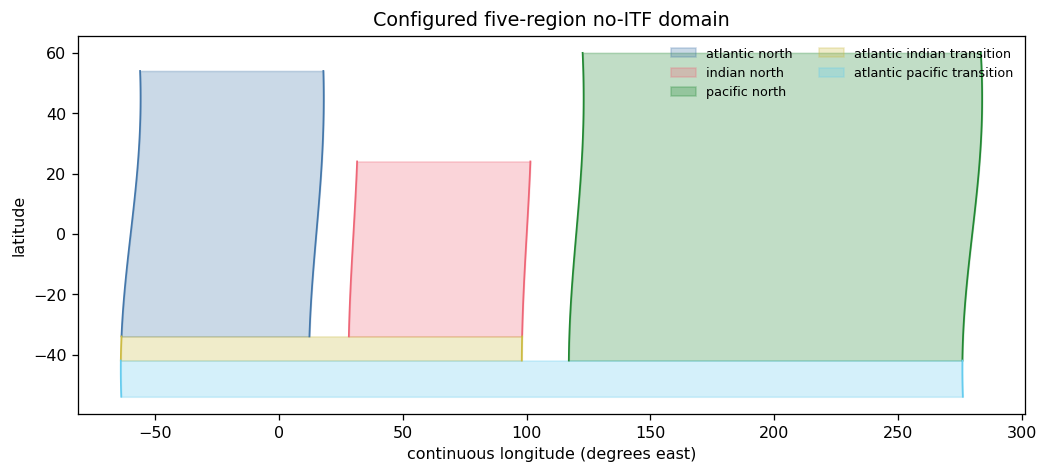

In [2]:
H = 1000.0
g_prime = 0.02
y_S, y_P, y_I, y_N = -54.0, -42.0, -34.0, 54.0
y_NI, y_NP = 24.0, 60.0
latitude_trace = np.arange(-60.0, 66.0, 2.0)

def trace(base, south, north, meander=0.0):
    values = np.full(latitude_trace.size, np.nan)
    active = (latitude_trace >= south) & (latitude_trace <= north)
    values[active] = base + meander * np.sin(np.deg2rad(2 * latitude_trace[active]))
    return ("latitude", values)

isobaths = xr.Dataset(
    {
        "x_wA": trace(-60.0, y_S, 64.0, 4.0),
        "x_eA": trace(15.0, y_I, 64.0, 3.0),
        "x_wI": trace(30.0, y_I, 30.0, 2.0),
        "x_eI": trace(100.0, y_P, 30.0, 2.0),
        "x_wP": trace(120.0, y_P, 62.0, 3.0),
        "x_eP": trace(280.0, y_S, 62.0, 4.0),
    },
    coords={"latitude": latitude_trace},
    attrs={"isobath_depth_m": H},
)

geometry = non_itf_geometry(
    isobaths,
    y_S=y_S,
    y_P=y_P,
    y_I=y_I,
    y_N=y_N,
    y_NI=y_NI,
    y_NP=y_NP,
)

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
plot_geometry(geometry, ax=ax)
ax.set_title("Configured five-region no-ITF domain")
plt.show()

## Vector-transport and boundary forcing

In [3]:
time = np.arange("1980-01", "2020-01", dtype="datetime64[M]")
latitude = np.arange(y_S, y_NP + 0.1, 2.0)
longitude = np.arange(0.0, 360.0, 4.0)
years = np.arange(time.size) / 12.0

taper = non_itf_taper(
    geometry,
    xr.DataArray(latitude, dims="latitude"),
    xr.DataArray(longitude, dims="longitude"),
    width_degrees=4.0,
)
wind_clock = xr.DataArray(
    np.sin(2 * np.pi * years / 9.0) + 0.45 * np.sin(2 * np.pi * years / 3.5),
    dims="time",
    coords={"time": time},
)
lat_shape = xr.DataArray(
    np.cos(np.deg2rad(latitude)), dims="latitude", coords={"latitude": latitude}
)
lon_shape = xr.DataArray(
    np.sin(np.deg2rad(longitude)), dims="longitude", coords={"longitude": longitude}
)

M_ek_y = (0.12 * wind_clock * lat_shape * taper).transpose(
    "time", "latitude", "longitude"
)
M_ek_x = (0.04 * wind_clock * lat_shape * lon_shape * taper).transpose(
    "time", "latitude", "longitude"
)
M_ek_y.attrs.update(units="m2 s-1", positive="northward")
M_ek_x.attrs.update(units="m2 s-1", positive="eastward")

northern = xr.DataArray(
    8.0 * np.exp(-0.5 * ((years - 12.0) / 1.4) ** 2)
    + 2.0 * np.sin(2 * np.pi * years / 6.0),
    dims="time",
    coords={"time": time},
    attrs={"units": "Sv", "positive": "northward"},
)
southern = section_transport(
    M_ek_y,
    geometry,
    region="atlantic_pacific_transition",
    latitude=y_S,
)

forcing = GlobalForcing.from_time_series(
    M_ek_x=M_ek_x,
    M_ek_y=M_ek_y,
    northern_transport=northern,
    southern_transport=southern,
    sample_interval_seconds=365.25 * 86_400 / 12,
    padding_samples=time.size - 1,
    n_fft=2048,
)
output = GlobalAdjustmentModel(geometry, forcing, g_prime=g_prime).solve()

## Propagation through the step-shaped Atlantic

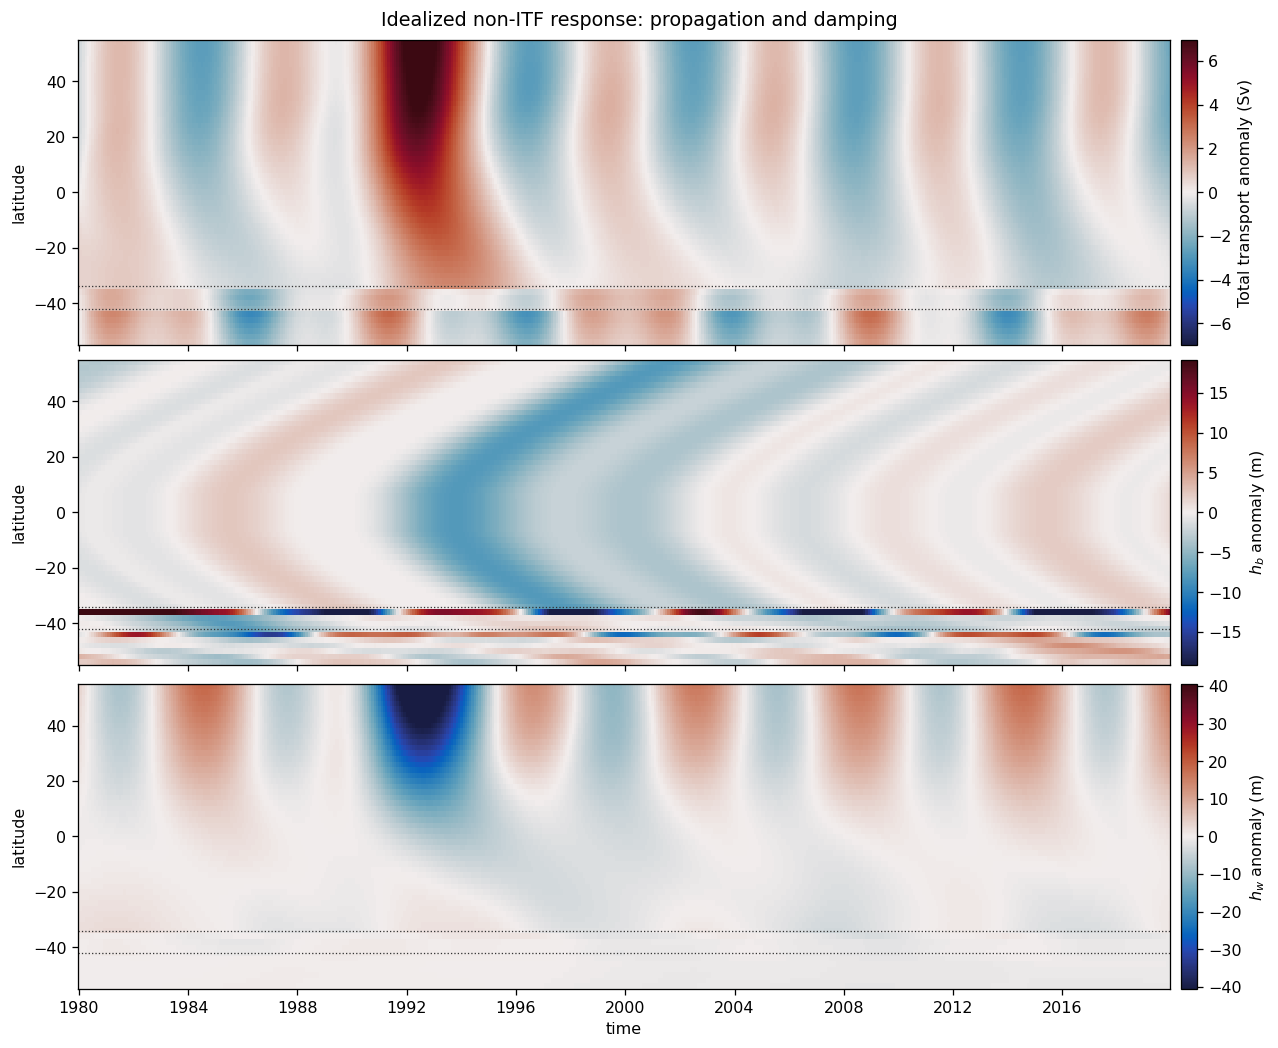

In [4]:
atlantic = xr.Dataset(
    {
        "transport": stitched_atlantic(output.transport / 1e6, geometry),
        "h_b": stitched_atlantic(output.h_b, geometry),
        "h_w": stitched_atlantic(output.h_w, geometry),
    }
)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, constrained_layout=True)
specs = [
    ("transport", "Total transport anomaly (Sv)"),
    ("h_b", r"$h_b$ anomaly (m)"),
    ("h_w", r"$h_w$ anomaly (m)"),
]
for ax, (name, label) in zip(axes, specs):
    field = atlantic[name]
    vmax = float(abs(field).quantile(0.995))
    mesh = field.plot.pcolormesh(
        ax=ax,
        x="time",
        y="latitude",
        cmap=cmocean.cm.balance,
        norm=mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax),
        add_colorbar=False,
        rasterized=True,
    )
    fig.colorbar(mesh, ax=ax, pad=0.01, label=label)
    ax.axhline(y_P, color="0.2", linestyle=":", linewidth=0.8)
    ax.axhline(y_I, color="0.2", linestyle=":", linewidth=0.8)
    ax.set(xlabel="", ylabel="latitude")
axes[-1].set_xlabel("time")
fig.suptitle("Idealized non-ITF response: propagation and damping")
plt.show()

## Northern-forcing damping factor

To diagnose the linear response without mixing in a forcing spectrum, the
next calculation uses a one-sample northern impulse and zero
$\mathbf{M}_{\mathrm{Ek}}$. Its nonzero Fourier coefficients are constant, so the
ratio below is the transport transfer amplitude itself.

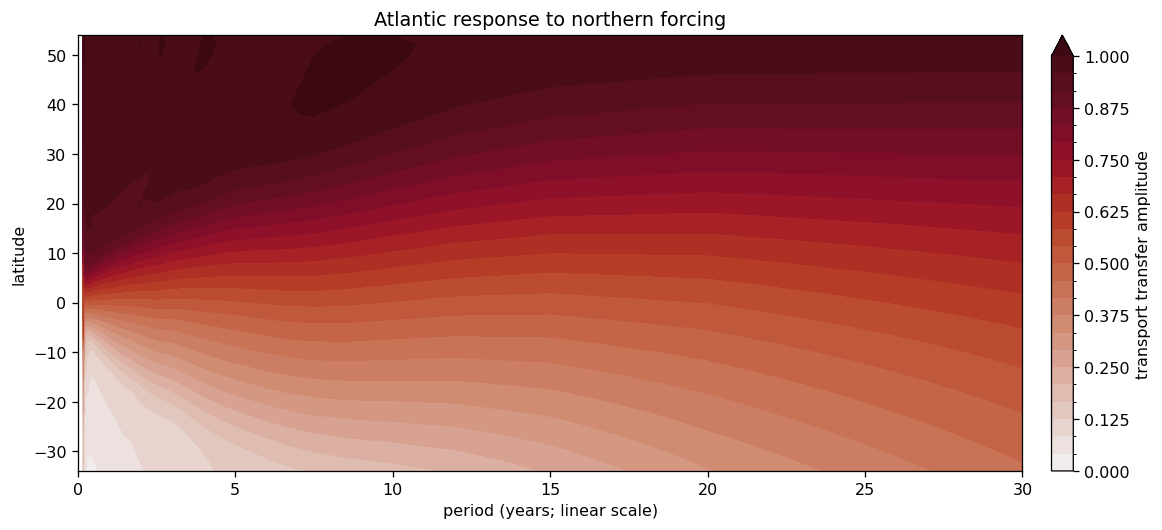

In [5]:
transfer_time = np.arange("2000-01", "2060-01", dtype="datetime64[M]")  # 720 months
zeros = xr.DataArray(
    np.zeros((transfer_time.size, latitude.size, longitude.size)),
    dims=("time", "latitude", "longitude"),
    coords={"time": transfer_time, "latitude": latitude, "longitude": longitude},
    attrs={"units": "m2 s-1"},
)
impulse = xr.DataArray(
    np.r_[1.0, np.zeros(transfer_time.size - 1)],
    dims="time",
    coords={"time": transfer_time},
    attrs={"units": "Sv"},
)
zero_transport = xr.zeros_like(impulse)
zero_transport.attrs["units"] = "Sv"
transfer_forcing = GlobalForcing.from_time_series(
    M_ek_x=zeros,
    M_ek_y=zeros,
    northern_transport=impulse,
    southern_transport=zero_transport,
    sample_interval_seconds=365.25 * 86_400 / 12,
    padding_samples=0,
    n_fft=720,
)
transfer_output = GlobalAdjustmentModel(
    geometry, transfer_forcing, g_prime=g_prime
).solve()

response = transfer_output.spectral.transport.sel(region="atlantic_north").dropna(
    "latitude", how="all"
)
response = response.isel(omega=slice(1, None))
source = transfer_forcing.spectral.northern_transport.isel(omega=slice(1, None))
period_years = (
    2 * np.pi / response.omega / (365.25 * 86_400)
).rename("period_years")
damping = abs(response / source).assign_coords(period_years=period_years)
damping = damping.swap_dims({"omega": "period_years"}).sortby("period_years")
damping = damping.sel(period_years=slice(0.0, 30.0))

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
levels = np.linspace(0.0, float(damping.quantile(0.99)), 25)
mesh = damping.plot.contourf(
    ax=ax,
    x="period_years",
    y="latitude",
    levels=levels,
    cmap=cmocean.cm.amp,
    extend="max",
    add_colorbar=False,
)
fig.colorbar(mesh, ax=ax, pad=0.02, label="transport transfer amplitude")
ax.set(
    xlabel="period (years; linear scale)",
    ylabel="latitude",
    title="Atlantic response to northern forcing",
    xlim=(0, 30),
)
plt.show()